In [1]:
!pip install --pre torch torchvision --index-url https://download.pytorch.org/whl/nightly/cu128
!pip install yfinance torch scikit-learn matplotlib pandas numpy
!pip install pandas_market_calendars

Looking in indexes: https://download.pytorch.org/whl/nightly/cu128
  Using cached https://download-r2.pytorch.org/whl/nightly/cu128/torchvision-0.27.0.dev20260407%2Bcu128-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
ERROR: Cannot install torch and torchvision==0.27.0.dev20260407+cu128 because these package versions have conflicting dependencies.

The conflict is caused by:
    The user requested torch
    torchvision 0.27.0.dev20260407+cu128 depends on torch==2.12.0.dev20260407

To fix this you could try to:
1. loosen the range of package versions you've specified
2. remove package versions to allow pip attempt to solve the dependency conflict

ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


# Importando Bibliotecas

In [2]:
import math
import torch
import numpy as np
import pandas as pd
import yfinance as yf
import torch.nn as nn
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

## Verificando disponibilidade de Gpu

In [3]:
print("GPU disponível:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Modelo da GPU:", torch.cuda.get_device_name(0))

GPU disponível: True
Modelo da GPU: NVIDIA GeForce RTX 5080


# Definindo funções para treinamento da I.A

### Função para buscar dos dados da Ação na bolsa e retornar o volume e o preço de fechamento.

In [4]:
def get_data(start_date:str, end_date:str, ticker:str="PETR4.SA"):
    df = yf.download(ticker, start=start_date, end=end_date)
    return df[['Close', 'Volume']]

### Função para Avaliação do modelo treinado.

In [5]:
def model_evaluation_diff(message: str, scaler_y, model_predictions, y_test, real_close_prices, window_size):
    # 1. Desnormaliza apenas as diferenças/retornos
    pred_diffs = scaler_y.inverse_transform(model_predictions)
    real_diffs = scaler_y.inverse_transform(y_test)
    
    # 2. Alinha os preços de fechamento originais correspondentes ao período de teste
    # Precisamos pegar o preço do dia anterior (t-1) para somar com a variação prevista
    base_prices = real_close_prices[-len(pred_diffs)-1 : -1].reshape(-1, 1)
    
    # Reconstroi os preços em R$
    predictions_price = base_prices + pred_diffs
    real_values_price = base_prices + real_diffs
    
    # Cálculo de erro sobre o preço final reconstruído
    mae = mean_absolute_error(real_values_price, predictions_price)
    mape = mean_absolute_percentage_error(real_values_price, predictions_price) * 100
    rmse = np.sqrt(np.mean((real_values_price - predictions_price) ** 2))
    
    print(message)
    print("-" * 50)
    print(f"MAE  (Erro Médio Absoluto)    : R$ {mae:.2f}")
    print(f"MAPE (Erro Percentual Médio)  : {mape:.2f}%")
    print(f"RMSE (Raiz do Erro Quadrático): R$ {rmse:.2f}")
    print("-" * 50)

### Função para criar as janelas de dados para treinamento da I.A

In [6]:
# Recriar a função de sequências adaptada para múltiplas features
def generate_multi_sequences(X_data, y_data, time_window=60):
    X, y = [], []
    for i in range(len(X_data) - time_window):
        X.append(X_data[i : i + time_window])
        y.append(y_data[i + time_window])
    return np.array(X), np.array(y)

### Função para separar os dados nos tensores X e Y para treinamento do modelo.

In [7]:
def split_data_in_tensors(X,y,seed=42):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, shuffle=False)

    # 2. Converter os arrays NumPy para Tensores do PyTorch (tipo float32)
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
    
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
    print(f"Treino - X: {X_train_tensor.shape}, y: {y_train_tensor.shape}")
    print(f"Teste  - X: {X_test_tensor.shape}, y: {y_test_tensor.shape}")
    return X_train_tensor,y_train_tensor,X_test_tensor,y_test_tensor,X_train, X_test, y_train, y_test


### Função para treinamento do modelo por épocas.

In [8]:
def train_AI(model,optimizer,criterion,X_train_tensor,y_train_tensor,epochs):
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        predictions= model(X_train_tensor)
        loss = criterion(predictions, y_train_tensor)
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 10 == 0:
            print(f"Época [{epoch+1}/{EPOCHS}] -> Erro (Loss): {loss.item():.6f}")
    

# Definindo estrura da rede neural

 Foram criadas duas camadas escondidas de LSTM(Long short-term memory) com 50 "neurônios" cada, com um input de 2 variáveis para a classificação binária, na camada seguinte a essas duas é um "neurônio" fully-connected que transforma a saida dos 50 anteriores em apenas uma que é um sigmoid para transformar a classificação em "Caiu (0)", "Subiu (1)".

Já no forward, explicando de maneira sucinta, é onde são feita as ligações das camadas definidas anteriormente e definido o caminho que X(janela de dias recebidos) percorre até a previsão do dia seguinte.

In [9]:
class SharesPredictionModel(nn.Module):
    def __init__(self, input_size=2, hidden_size=50, num_layers=2):
        super(SharesPredictionModel, self).__init__()
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.1)
        
        self.fc = nn.Linear(hidden_size, 1)

        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        out, _ = self.lstm(x)
        
        out = out[:, -1, :]
    
        out = self.fc(out)
        out = self.sigmoid(out)
        return out

# Treinamento

In [10]:
ticker="PETR4.SA"
data=get_data("2021-01-01","2026-06-13",ticker)
data['Price_Diff'] = data['Close'].diff()
data = data.dropna()

#Converte valores positivos para 1 e negativos para 0
data['Target'] = (data['Price_Diff'] > 0).astype(int)

#definindo a variável alvo e as demais variáveis para o treinamento.
X_features = data[['Price_Diff', 'Volume']].values
y_target = data['Target'].values.reshape(-1, 1)

# Normalizar os dados de feature entre 0 e 1
scaler_X = MinMaxScaler(feature_range=(0, 1))
normalized_X = scaler_X.fit_transform(X_features)

#gerando janelas de tempo de dez dias para treinamento de modelo.
WINDOW = 10
X, y = generate_multi_sequences(normalized_X, y_target, WINDOW)

print(f"Formato de X (Amostras, Dias, Features): {X.shape}")
print(f"Formato de y (Amostras, Alvo): {y.shape}")

[*********************100%***********************]  1 of 1 completed

Formato de X (Amostras, Dias, Features): (1345, 10, 2)
Formato de y (Amostras, Alvo): (1345, 1)


 Os dados de treinamento(janelas temporais) são separados nos tensores, além disso são definidos o modelo, no formato que definimos antes, a função de perda do modelo como BCEloss(Perda de entropia cruzada binária) e otimizador de modelo como Adam(Adaptive Moment Estimation) e são passados para a função de treinamento do modelo, junto com o numero de epocas de treinamento.

In [11]:

X_train_tensor,y_train_tensor,X_test_tensor,y_test_tensor,X_train, X_test, y_train, y_test=split_data_in_tensors(X,y)

model = SharesPredictionModel()

EPOCHS = 200
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print("Iniciando o treinamento...")
train_AI(model,optimizer,criterion,X_train_tensor,y_train_tensor,EPOCHS)
print("Treinamento concluído!")


Treino - X: torch.Size([1076, 10, 2]), y: torch.Size([1076, 1])
Teste  - X: torch.Size([269, 10, 2]), y: torch.Size([269, 1])
Iniciando o treinamento...
Época [10/200] -> Erro (Loss): 0.691720
Época [20/200] -> Erro (Loss): 0.691646
Época [30/200] -> Erro (Loss): 0.691612
Época [40/200] -> Erro (Loss): 0.691550
Época [50/200] -> Erro (Loss): 0.691416
Época [60/200] -> Erro (Loss): 0.691463
Época [70/200] -> Erro (Loss): 0.690846
Época [80/200] -> Erro (Loss): 0.690060
Época [90/200] -> Erro (Loss): 0.690000
Época [100/200] -> Erro (Loss): 0.688201
Época [110/200] -> Erro (Loss): 0.688923
Época [120/200] -> Erro (Loss): 0.687899
Época [130/200] -> Erro (Loss): 0.689008
Época [140/200] -> Erro (Loss): 0.686718
Época [150/200] -> Erro (Loss): 0.688216
Época [160/200] -> Erro (Loss): 0.686784
Época [170/200] -> Erro (Loss): 0.686456
Época [180/200] -> Erro (Loss): 0.686042
Época [190/200] -> Erro (Loss): 0.686257
Época [200/200] -> Erro (Loss): 0.686461
Treinamento concluído!


# Avaliação do modelo

O modelo é posto em modo de avaliação , e avaliamos ele usando o accuracy_score do sklearn.

Em um primeiro momento a taxa de acurracia na casa dos 50 e poucos porcento parece baixa, porém realizando uma pesquisa descobri que para o mercado financeiro é perfeitamente aceitavel, inclusive um exemplo que achei foi o do fundo 
Medallion Fund da Renaissance Technologies cujo o modelo tinha a acuracia de 51% e ainda assim eles fizeram e fazem bilhões de  dólares no mercado de ações.

In [12]:
model.eval()

with torch.no_grad():
    test_predictions_prob = model(X_test_tensor).numpy()
    
test_predictions_classes = (test_predictions_prob >= 0.5).astype(int)

print("\n" + "=" * 50)
print("📊 RELATÓRIO DE CLASSIFICAÇÃO (TESTE)")
print("=" * 50)
accuracy = accuracy_score(y_test, test_predictions_classes)
print(f"Acurácia Global (Taxa de Acerto): {accuracy * 100:.2f}%\n")

print(classification_report(y_test, test_predictions_classes, target_names=["Caiu (0)", "Subiu (1)"]))


📊 RELATÓRIO DE CLASSIFICAÇÃO (TESTE)
Acurácia Global (Taxa de Acerto): 54.28%

              precision    recall  f1-score   support

    Caiu (0)       0.46      0.39      0.42       116
   Subiu (1)       0.59      0.66      0.62       153

    accuracy                           0.54       269
   macro avg       0.53      0.52      0.52       269
weighted avg       0.53      0.54      0.54       269



Abaixo foi realizado um backTesting, em que simulamos a I.A operando da bolsa, em que sempre que ela tem mais de 55% de certeza ela "Compra" a ação, e estimamos quantos % da subida do mercado ela aproveitaria.


--------------------------------------------------
💸 RESULTADO FINANCEIRO DO BACKTEST (Threshold: 55.00000000000001%)
--------------------------------------------------
Total de Dias no Teste        : 269 dias
Dias Operados (Comprado)      : 93 dias (34.6% do tempo)
--------------------------------------------------
Lucro Buy & Hold (Mercado)    : 44.80%
Lucro da Estratégia IA        : 18.73%
--------------------------------------------------


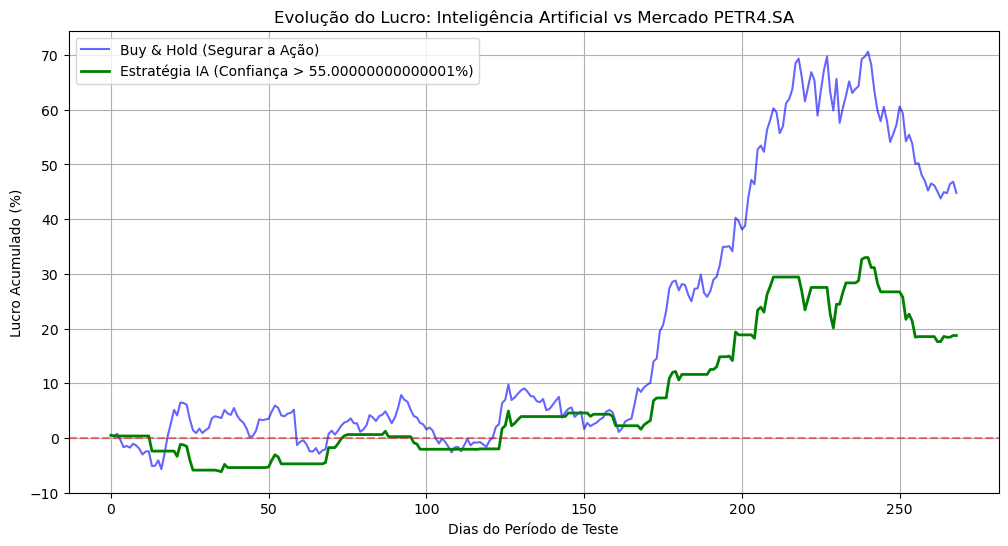

In [13]:

THRESHOLD = 0.55 

model.eval()
with torch.no_grad():
    test_probs = model(X_test_tensor).numpy().flatten()

buy_signals = (test_probs >= THRESHOLD).astype(int)

data['Daily_Return'] = data['Close'].pct_change()

test_size = len(buy_signals)
test_real_returns = data['Daily_Return'].dropna().values[-test_size:]

strategy_returns = buy_signals * test_real_returns


cumulative_market_return = (1 + test_real_returns).cumprod() - 1
cumulative_strategy_return = (1 + strategy_returns).cumprod() - 1

bought_days = np.sum(buy_signals)
percentage_market_time = (bought_days / test_size) * 100

print("\n" + "-" * 50)
print(f"💸 RESULTADO FINANCEIRO DO BACKTEST (Threshold: {THRESHOLD * 100}%)")
print("-" * 50)
print(f"Total de Dias no Teste        : {test_size} dias")
print(f"Dias Operados (Comprado)      : {bought_days} dias ({percentage_market_time:.1f}% do tempo)")
print("-" * 50)
print(f"Lucro Buy & Hold (Mercado)    : {cumulative_market_return[-1] * 100:.2f}%")
print(f"Lucro da Estratégia IA        : {cumulative_strategy_return[-1] * 100:.2f}%")
print("-" * 50)

plt.figure(figsize=(12, 6))
plt.plot(cumulative_market_return * 100, label="Buy & Hold (Segurar a Ação)", color="blue", alpha=0.6)
plt.plot(cumulative_strategy_return * 100, label=f"Estratégia IA (Confiança > {THRESHOLD*100}%)", color="green", linewidth=2)
plt.title(f"Evolução do Lucro: Inteligência Artificial vs Mercado {ticker}")
plt.ylabel("Lucro Acumulado (%)")
plt.xlabel("Dias do Período de Teste")
plt.legend()
plt.grid(True)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

# Salvando modelo(pesos e scaler)

Salvo os pesos no arquivo .pth que seriam o cérebro da I.A, e o scaler que seria o tradutor de dados da I.A .

In [14]:
import torch
import joblib

model_path = "ai_model_petr4.pth"
torch.save(model.state_dict(), model_path)
print(f"✅ Modelo salvo com sucesso em: {model_path}")

scaler_path = "X_scaler_petr4.pkl"
joblib.dump(scaler_X, scaler_path)
print(f"✅ Scaler salvo com sucesso em: {scaler_path}")

✅ Modelo salvo com sucesso em: ai_model_petr4.pth
✅ Scaler salvo com sucesso em: X_scaler_petr4.pkl


# Exemplo: Carregando modelo salvo

Abaixo tem um exemplo de como carregar o modelo treinado,apartir dos arquivos salvos, e como realizar uma inferência utilizando o modelo.

In [15]:
import torch
import joblib
import torch.nn as nn
import yfinance as yf


class SharesClassificationModel(nn.Module):
    def __init__(self, input_size=2, hidden_size=50, num_layers=2):
        super(SharesClassificationModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.1)
        self.fc = nn.Linear(hidden_size, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        out = self.sigmoid(out) 
        return out


loaded_X_scaler = joblib.load("X_scaler_petr4.pkl")

loaded_model = SharesClassificationModel(input_size=2, hidden_size=50, num_layers=2)

loaded_model.load_state_dict(torch.load("ai_model_petr4.pth"))

loaded_model.eval()

print("Modelo preditivo carregado!")

recent_data = yf.download("PETR4.SA", period="15d")
recent_data['Price_Diff'] = recent_data['Close'].diff()
recent_data = recent_data.dropna()

last_10_days = recent_data[['Price_Diff', 'Volume']].values[-10:]

last_10_days_normalized = loaded_X_scaler.transform(last_10_days)

ai_entrance = torch.tensor(last_10_days_normalized, dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    probability = loaded_model(ai_entrance).numpy()[0][0]

print("-" * 50)
print(f"📈 Probabilidade de Alta para o próximo dia: {probability * 100:.2f}%")
if probability >= 0.55:
    print("SINAL: 🟢 COMPRAR")
else:
    print("SINAL: 🔴 FICAR DE FORA (OU VENDER)")
print("-" * 50)

Modelo preditivo carregado!


[*********************100%***********************]  1 of 1 completed

--------------------------------------------------
📈 Probabilidade de Alta para o próximo dia: 67.11%
SINAL: 🟢 COMPRAR
--------------------------------------------------
